## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.animation import FuncAnimation, PillowWriter

# IDENTITY CONFIGURATION
student_name = "Raym Eamon Geromo"
student_id = "20250082" 

# 1. Load the dataset (Make sure the CSV is in your folder!)
df = pd.read_csv("spotify_top_1000_tracks.csv", encoding="utf-8")

# 2. Preprocess the data needed for the exercises
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
# Ensure duration is in minutes
if 'duration_ms' in df.columns:
    df['duration_min'] = df['duration_ms'] / 60000
    
# 3. Generate Personalized Colors
id_num = int(student_id[-3:])
color1 = f"#{(id_num * 7) % 256:02x}{(id_num * 3) % 256:02x}{(id_num * 5) % 256:02x}"
color2 = f"#{(id_num * 2) % 256:02x}{(id_num * 9) % 256:02x}{(id_num * 4) % 256:02x}"

print("Setup Complete! 'df' and 'plt' are now defined.")

Setup Complete! 'df' and 'plt' are now defined.


## Exercise 1 

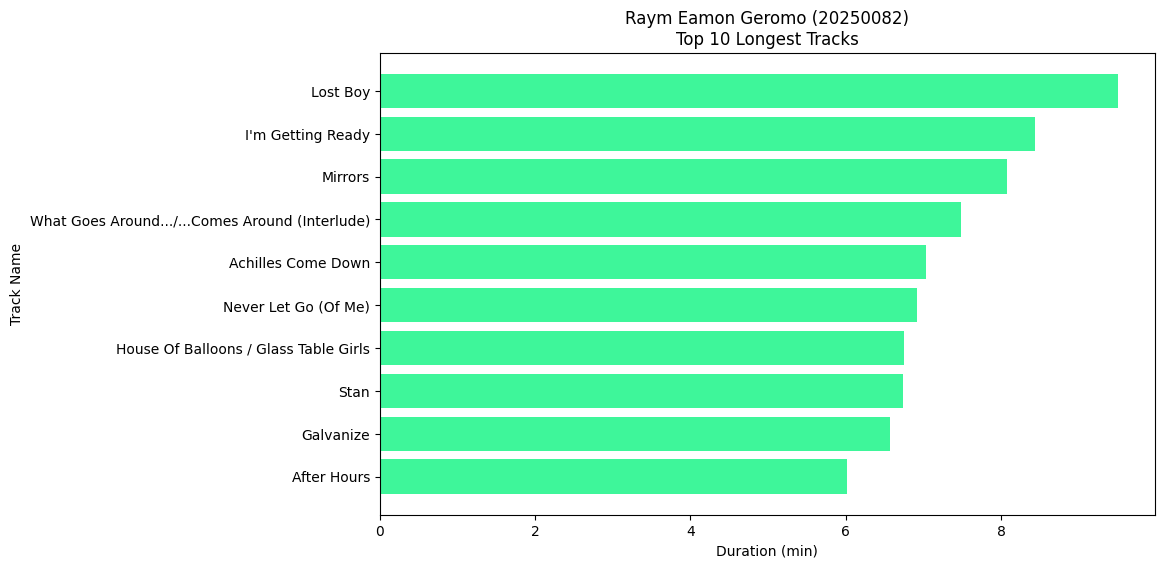

                                          track_name                 artist  \
710                                         Lost Boy                  Jaden   
610                                I'm Getting Ready    Tasha Cobbs Leonard   
64                                           Mirrors      Justin Timberlake   
63   What Goes Around.../...Comes Around (Interlude)      Justin Timberlake   
622                               Achilles Come Down         Gang of Youths   
689                             Never Let Go (Of Me)                 Baltra   
682            House Of Balloons / Glass Table Girls             The Weeknd   
549                                             Stan                 Eminem   
671                                        Galvanize  The Chemical Brothers   
37                                       After Hours             The Weeknd   

     duration_min  
710      9.497883  
610      8.436667  
64       8.069100  
63       7.476217  
622      7.035767  
689      6

In [2]:
# Sort by duration and pick top 10
longest_tracks = df.nlargest(10, 'duration_min')[['track_name', 'artist', 'duration_min']]

plt.figure(figsize=(10, 6))
# Create horizontal bar chart
plt.barh(longest_tracks['track_name'], longest_tracks['duration_min'], color=color1)
plt.xlabel('Duration (min)')
plt.ylabel('Track Name')
plt.title(f"{student_name} ({student_id})\nTop 10 Longest Tracks")
plt.gca().invert_yaxis() # Puts the longest track at the top
plt.show()

print(longest_tracks)

## Exercise 2

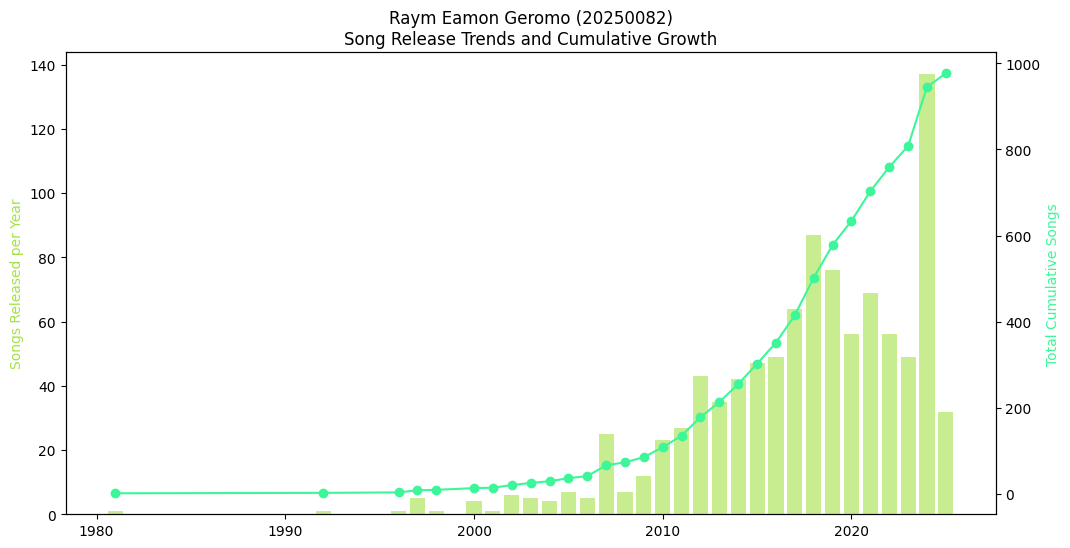

In [3]:
# Group by year and calculate counts
yearly_counts = df.groupby('release_year').size().reset_index(name='count')
yearly_counts['cumulative'] = yearly_counts['count'].cumsum()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar chart (Left Axis)
ax1.bar(yearly_counts['release_year'], yearly_counts['count'], color=color2, alpha=0.6, label='Yearly Count')
ax1.set_ylabel('Songs Released per Year', color=color2)

# Line chart (Right Axis)
ax2 = ax1.twinx()
ax2.plot(yearly_counts['release_year'], yearly_counts['cumulative'], color=color1, marker='o', label='Cumulative Total')
ax2.set_ylabel('Total Cumulative Songs', color=color1)

plt.title(f"{student_name} ({student_id})\nSong Release Trends and Cumulative Growth")
plt.show()

## Exercise 3

In [4]:
# Prepare the animation figure
fig, ax = plt.subplots(figsize=(10, 6))
# Clean the years list (remove NaNs)
years_list = sorted(df['release_year'].dropna().unique())

def update_hex(frame):
    ax.clear()
    current_year = years_list[frame]
    # Filter data up to the current frame year
    data_subset = df[df['release_year'] <= current_year]
    
    # Create the hexbin density map
    hb = ax.hexbin(data_subset['duration_min'], data_subset['popularity'], 
                   gridsize=20, cmap='coolwarm', mincnt=1)
    
    ax.set_title(f"{student_name} ({student_id})\nData Evolution up to {int(current_year)}")
    ax.set_xlabel('Duration (min)')
    ax.set_ylabel('Popularity')
    return hb,

# Create the animation
ani_hex = FuncAnimation(fig, update_hex, frames=len(years_list), interval=200, repeat=False)

# Save the GIF (Make sure you have 'pillow' installed)
hex_gif_path = os.path.abspath("duration_popularity_evolution.gif")
ani_hex.save(hex_gif_path, writer=PillowWriter(fps=5))
print(f"Animation saved at: {hex_gif_path}")
plt.close()

Animation saved at: c:\Users\farah\OneDrive\Documents\VsCode\Lab7_DataVisulization_Geromo\duration_popularity_evolution.gif
